In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../src/data/train/6.csv", parse_dates=["timestamp"])
df.head()

,timestamp,distance,temperature,co2,humidity,stage
0,2026-02-19 15:05:31,97,26.1,1664,71.9,0
1,2026-02-19 15:22:29,97,26.8,1636,75.4,0
2,2026-02-19 15:23:31,97,32.6,1702,63.6,0
3,2026-02-19 15:24:32,98,32.9,1697,63.0,0
4,2026-02-19 15:25:32,98,33.0,1697,62.5,0


In [5]:
df.dtypes

timestamp      datetime64[ns]
distance                int64
temperature           float64
co2                     int64
humidity              float64
stage                   int64
dtype: object

In [16]:
# - Temperature in Celsius
# - Humidity in percentage
# - CO2 in ppm
# - Distance in millimeters
# Rise in millimeters
# Elapsed time in minutes
# Rise, CO2 slope over multiple windows (5, 10, 15 minutes)
# Rise, CO2 rolling mean and std over multiple windows (5, 10 minutes)
# Rise acceleration (5 minutes)
# ! Rise percentage (distance - starting-distance) / (starting-distance - jar distance)
#   - Missing jar distance
# Drop from peak mm and pct
# CO2 per rise mm

WINDOWS = {"short": 5, "medium": 15, "long": 30}


f = pd.DataFrame(index=df.index)
print(df["humidity"].corr(df["co2"]))
f["temperature"] = df["temperature"]
f["humidity"] = df["humidity"]
f["co2"] = df["co2"]
f["distance"] = df["distance"]

f["rise_mm"] = df["distance"].iloc[0] - df["distance"]
f["elapsed_min"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds() / 60

for k, v in WINDOWS.items():
    f[f"rise_mm_slope_{k}"] = f["rise_mm"].diff(v) / v
    f[f"co2_slope_{k}"] = f["co2"].diff(v) / v
    f[f"rise_mm_roll_mean_{k}"] = f["rise_mm"].rolling(v).mean()
    f[f"rise_mm_roll_std_{k}"] = f["rise_mm"].rolling(v).std()
    f[f"co2_roll_mean_{k}"] = f["co2"].rolling(v).mean()
    f[f"co2_roll_std_{k}"] = f["co2"].rolling(v).std()

f["rise_accel_short"] = f["rise_mm_slope_short"].diff() / WINDOWS["short"]
f["drop_from_peak_mm"] = f["rise_mm"].cummax() - f["rise_mm"]
f["drop_from_peak_pct"] = f["drop_from_peak_mm"] / f["rise_mm"].cummax()
f["co2_per_rise_mm"] = f["co2"] / f["rise_mm"]

# f.head()
f.corr(method="kendall")

0.07543804323317906


,temperature,humidity,co2,distance,rise_mm,elapsed_min,rise_mm_slope_short,co2_slope_short,rise_mm_roll_mean_short,rise_mm_roll_std_short,co2_roll_mean_short,co2_roll_std_short,rise_mm_slope_medium,co2_slope_medium,rise_mm_roll_mean_medium,rise_mm_roll_std_medium,co2_roll_mean_medium,co2_roll_std_medium,rise_mm_slope_long,co2_slope_long,rise_mm_roll_mean_long,rise_mm_roll_std_long,co2_roll_mean_long,co2_roll_std_long,rise_accel_short,drop_from_peak_mm,drop_from_peak_pct,co2_per_rise_mm
temperature,1.000000,0.490181,0.452744,-0.101190,0.101190,0.700219,-0.294305,-0.150272,0.085970,-0.009876,0.475544,0.325841,-0.530094,-0.045612,0.106135,-0.301075,0.466611,0.355413,-0.577817,-0.119838,0.132952,-0.414196,0.426932,0.283182,0.016650,0.649207,0.523428,0.359969
humidity,0.490181,1.000000,0.002024,-0.014687,0.014687,0.697076,-0.114544,-0.133341,-0.008308,-0.094812,0.039927,0.002698,-0.181129,-0.252284,-0.087630,-0.416888,0.059172,-0.004271,-0.203646,-0.358213,-0.186372,-0.508762,0.061403,-0.020788,0.004174,0.537462,0.430233,-0.101434
co2,0.452744,0.002024,1.000000,-0.534018,0.534018,0.202620,-0.267653,0.030127,0.566696,0.086002,0.907046,0.688477,-0.387002,0.159548,0.631591,0.053792,0.789470,0.714636,-0.347956,0.239974,0.706296,0.074078,0.674779,0.646688,-0.010263,0.156531,-0.007340,0.683972
distance,-0.101190,-0.014687,-0.534018,1.000000,-1.000000,0.070446,-0.058474,-0.025785,-0.908188,-0.080659,-0.515487,-0.539044,-0.034147,-0.133443,-0.820581,-0.176367,-0.457634,-0.493475,-0.128640,-0.201177,-0.682084,-0.203848,-0.375065,-0.433708,-0.033424,0.308879,0.524537,-0.182638
rise_mm,0.101190,0.014687,0.534018,-1.000000,1.000000,-0.070446,0.058474,0.025785,0.908188,0.080659,0.515487,0.539044,0.034147,0.133443,0.820581,0.176367,0.457634,0.493475,0.128640,0.201177,0.682084,0.203848,0.375065,0.433708,0.033424,-0.308879,-0.524537,0.182638
elapsed_min,0.700219,0.697076,0.202620,0.070446,-0.070446,1.000000,-0.254488,-0.064647,-0.091285,-0.072544,0.201121,0.091546,-0.376493,-0.117330,-0.123157,-0.426824,0.194261,0.065144,-0.400700,-0.206964,-0.175064,-0.574829,0.184939,0.038274,-0.010262,0.776351,0.673034,0.119226
rise_mm_slope_short,-0.294305,-0.114544,-0.267653,-0.058474,0.058474,-0.254488,1.000000,-0.201129,-0.026362,-0.004687,-0.233276,-0.207758,0.509674,-0.099099,-0.119777,0.157951,-0.210583,-0.222441,0.379536,-0.060471,-0.160577,0.218090,-0.197359,-0.195905,0.351664,-0.389843,-0.399653,-0.353839
co2_slope_short,-0.150272,-0.133341,0.030127,-0.025785,0.025785,-0.064647,-0.201129,1.000000,0.061150,0.041285,-0.050399,0.037295,0.076239,0.298948,0.057918,0.121934,-0.142845,-0.051731,0.174839,0.271584,0.019818,0.112144,-0.125495,-0.083256,-0.072741,-0.101583,-0.085115,0.065351
rise_mm_roll_mean_short,0.085970,-0.008308,0.566696,-0.908188,0.908188,-0.091285,-0.026362,0.061150,1.000000,0.093573,0.538325,0.568423,-0.032634,0.155946,0.878599,0.173228,0.469763,0.520045,0.077342,0.206330,0.730932,0.181623,0.387402,0.456942,-0.028334,-0.251746,-0.430959,0.239784
rise_mm_roll_std_short,-0.009876,-0.094812,0.086002,-0.080659,0.080659,-0.072544,-0.004687,0.041285,0.093573,1.000000,0.090355,0.067527,-0.013581,0.177361,0.095557,0.204192,0.014082,0.043082,0.063081,0.139352,0.079664,0.058450,-0.020073,0.035931,0.035866,-0.073683,-0.123590,0.039148


In [7]:
f.columns

Index(['temperature', 'humidity', 'co2', 'distance', 'rise_mm', 'elapsed_min',
       'rise_mm_slope_short', 'co2_slope_short', 'rise_mm_roll_mean_short',
       'rise_mm_roll_std_short', 'co2_roll_mean_short', 'co2_roll_std_short',
       'rise_mm_slope_medium', 'co2_slope_medium', 'rise_mm_roll_mean_medium',
       'rise_mm_roll_std_medium', 'co2_roll_mean_medium',
       'co2_roll_std_medium', 'rise_mm_slope_long', 'co2_slope_long',
       'rise_mm_roll_mean_long', 'rise_mm_roll_std_long', 'co2_roll_mean_long',
       'co2_roll_std_long', 'rise_accel_short', 'drop_from_peak_mm',
       'drop_from_peak_pct', 'co2_per_rise_mm'],
      dtype='object')

<Axes: title={'center': 'Elapsed Time (min)'}>

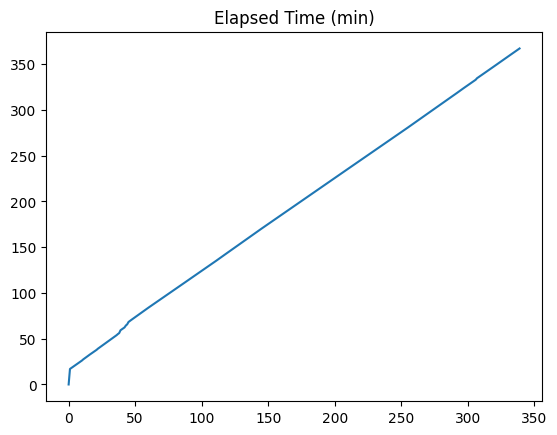

In [8]:
# 'temperature',
# 'humidity',
# 'co2',
# 'distance',

# 'elapsed_min',
f["elapsed_min"].plot(title="Elapsed Time (min)")

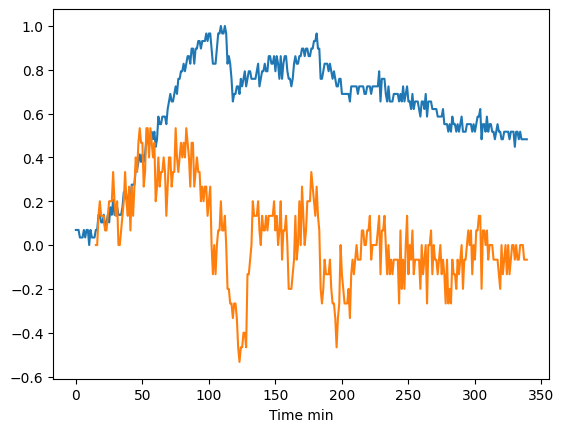

In [9]:
# 'rise_mm',
# 'rise_mm_slope_short',
# 'rise_mm_slope_medium',
# 'rise_mm_slope_long',

rise_mm_norm = (f["rise_mm"] - f["rise_mm"].min()) / (f["rise_mm"].max() - f["rise_mm"].min())
plt.plot(rise_mm_norm)
# plt.plot(f["rise_mm_slope_short"])
plt.plot(f["rise_mm_slope_medium"])
# plt.plot(f["rise_mm_slope_long"])
plt.xlabel("Time min")
plt.show()

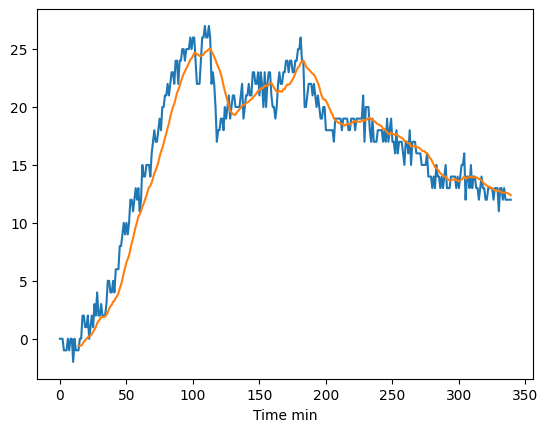

In [10]:
# 'rise_mm_roll_mean_short',
# 'rise_mm_roll_mean_medium',c
# 'rise_mm_roll_mean_long',

plt.plot(f["rise_mm"])
# plt.plot(f["rise_mm_roll_mean_short"])
plt.plot(f["rise_mm_roll_mean_medium"])
# plt.plot(f["rise_mm_roll_mean_long"])
plt.xlabel("Time min")
plt.show()

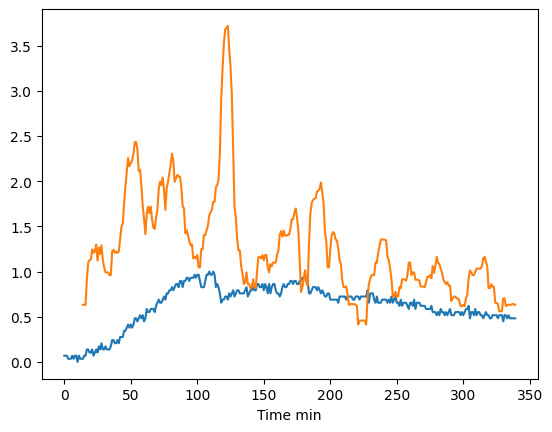

In [11]:
# 'rise_mm_roll_std_short',
# 'rise_mm_roll_std_medium',
# 'rise_mm_roll_std_long',

rise_mm_norm = (f["rise_mm"] - f["rise_mm"].min()) / (
    f["rise_mm"].max() - f["rise_mm"].min()
)
plt.plot(rise_mm_norm)
# plt.plot(f["rise_mm_roll_std_short"])
plt.plot(f["rise_mm_roll_std_medium"])
# plt.plot(f["rise_mm_roll_std_long"])
plt.xlabel("Time min")
plt.show()

<Axes: title={'center': 'Rise Acceleration (short)'}>

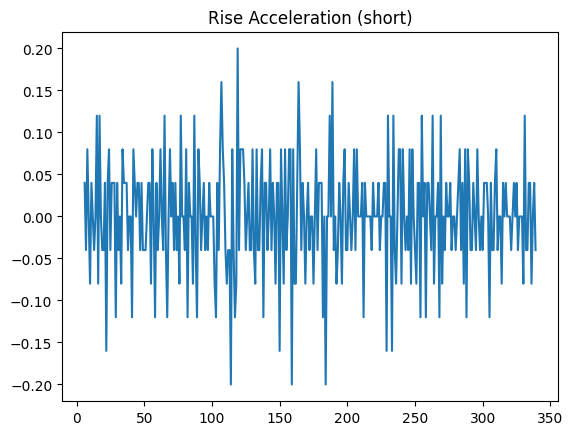

In [12]:
# 'rise_accel_short',
f["rise_accel_short"].plot(title="Rise Acceleration (short)")


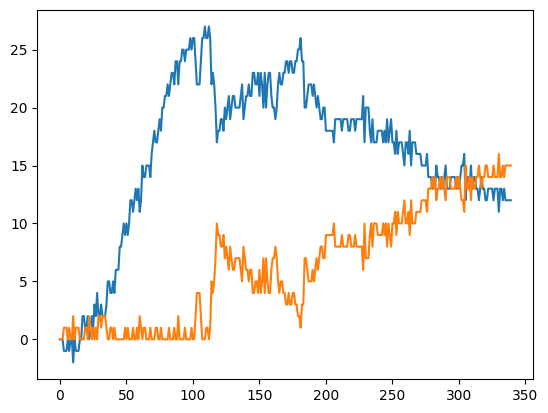

In [13]:
# 'drop_from_peak_mm',\
plt.plot(f["rise_mm"])
plt.plot(f["drop_from_peak_mm"])
plt.show()



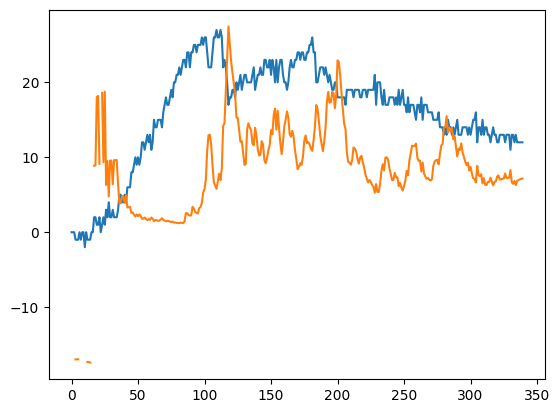

In [14]:
plt.plot(f["rise_mm"])
co2_per_rise_mm_norm = (f["co2_per_rise_mm"] / 100)
plt.plot(co2_per_rise_mm_norm)
plt.show()

<Axes: >

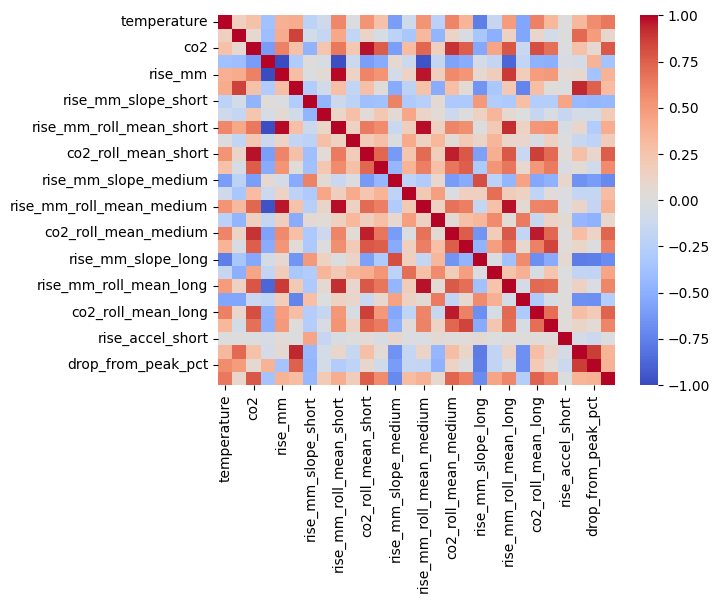

In [15]:
sns.heatmap(f.corr(), annot=False, fmt=".2f", cmap="coolwarm")